In [76]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1.EDA

In [77]:
# Citirea fișierul CSV
df = pd.read_csv('cluster_1.csv')

In [78]:
# Verificarea primelor 5 rânduri pentru a confirma încărcarea corectă
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


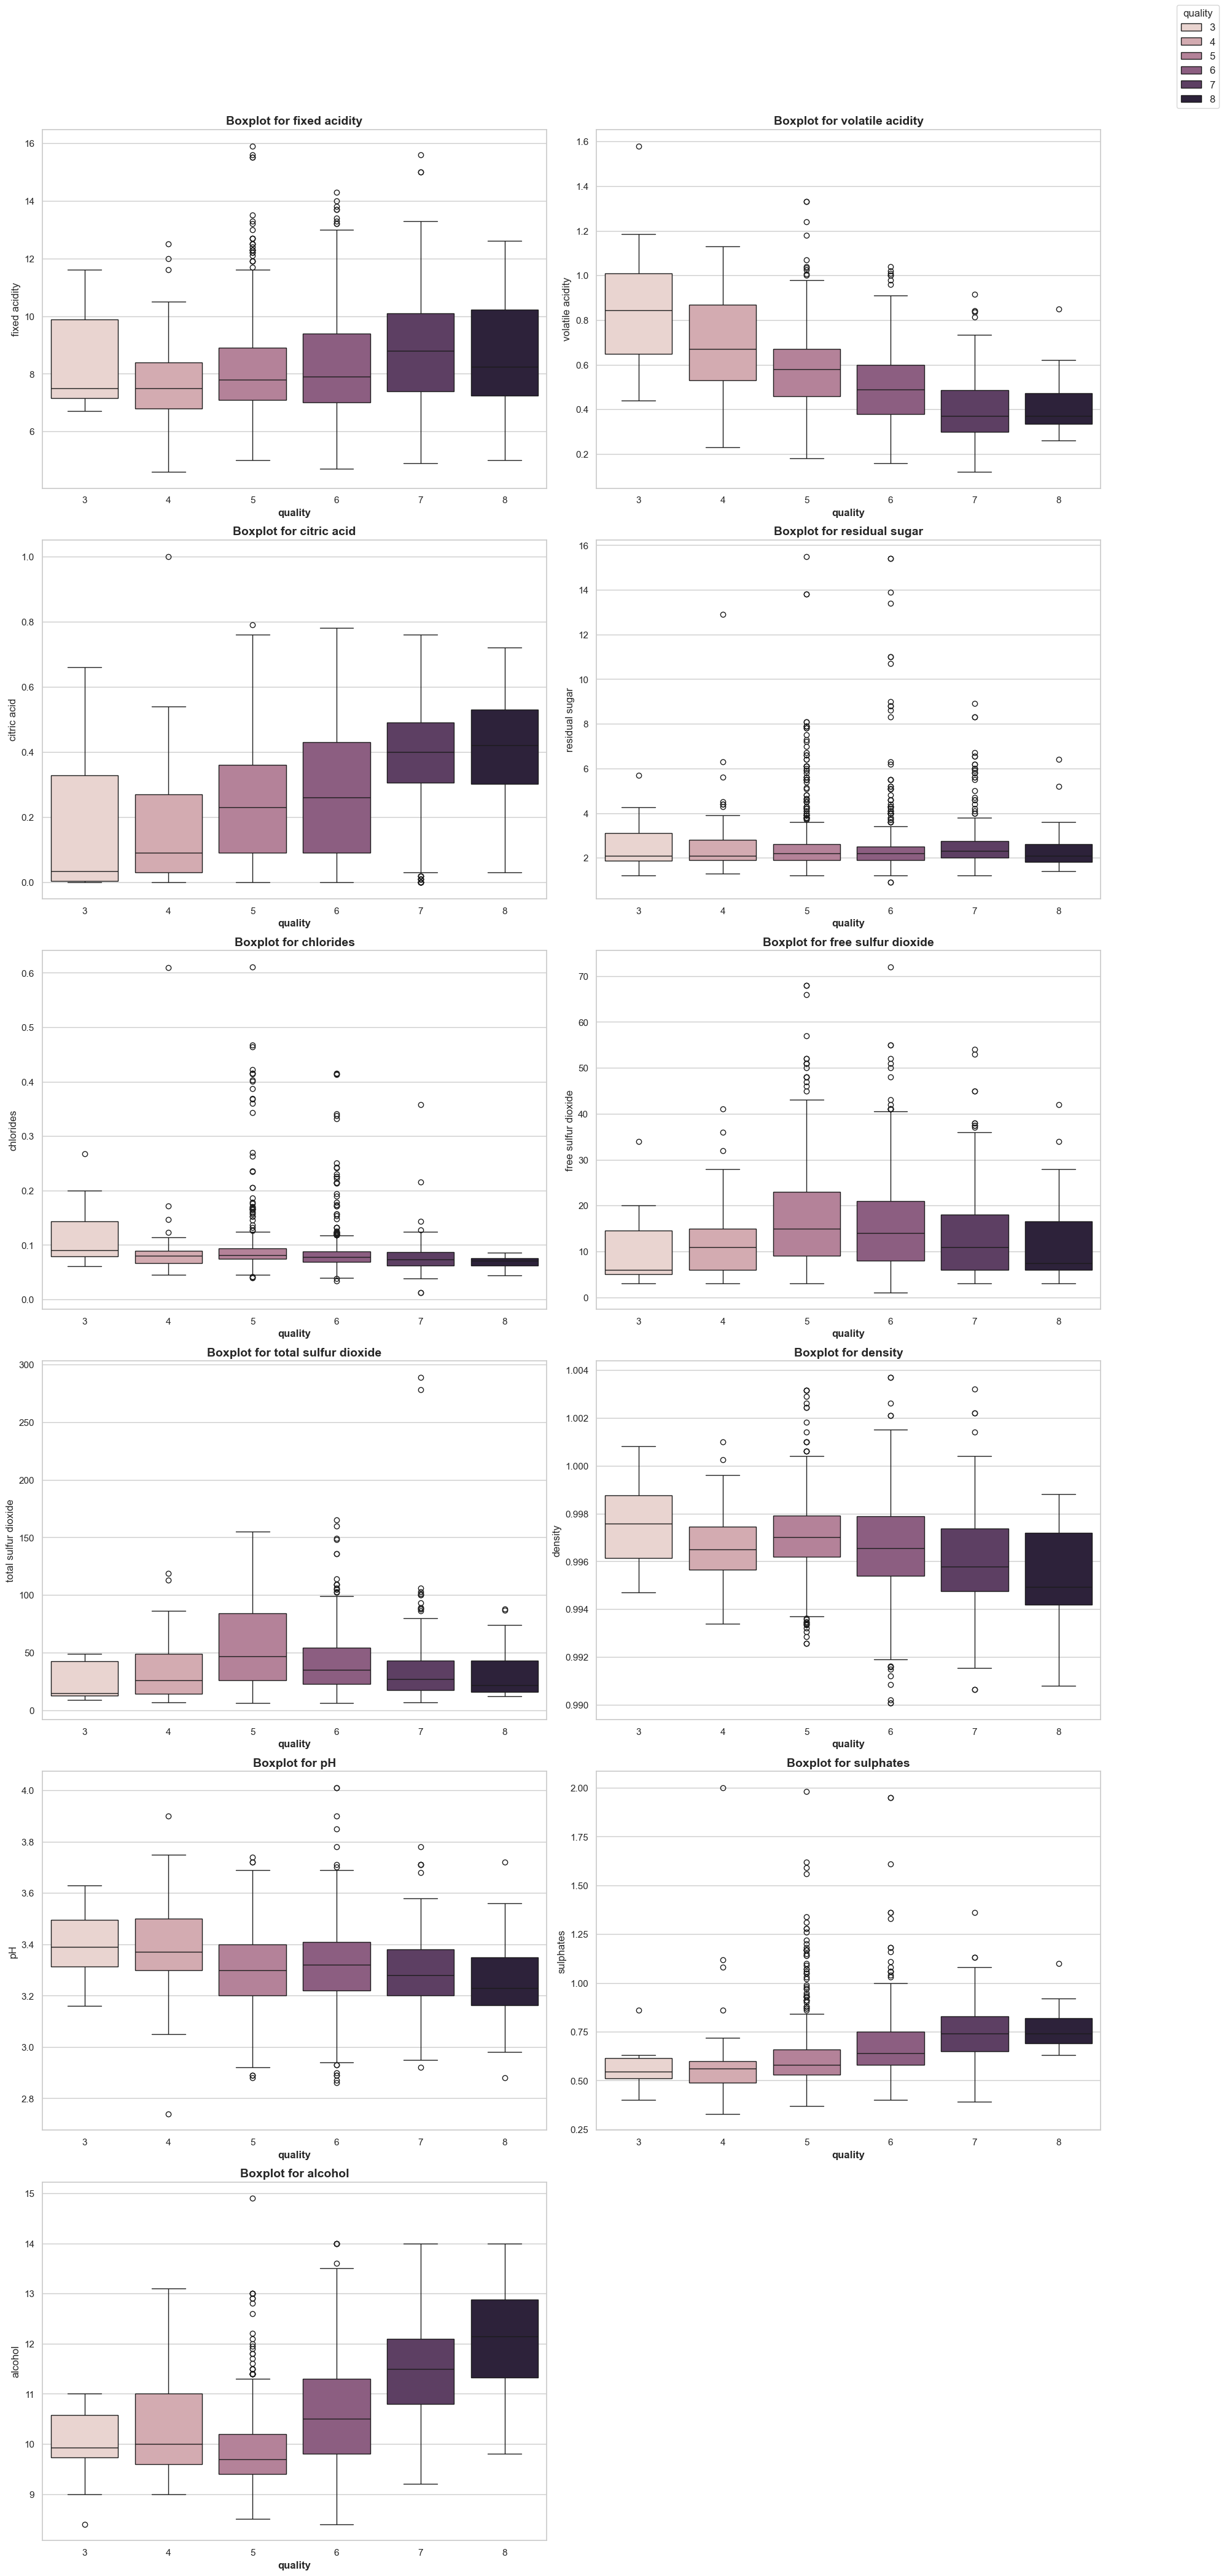

In [79]:
sns.set(style="whitegrid")

# Selectăm coloanele numerice dorite
columns = df.drop('quality', axis=1).columns

# Setăm grid-ul de subplot-uri
n_cols = 2
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 7*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x='quality', y=col, hue='quality', data=df,
                 dodge=False, ax=axes[i])
    axes[i].set_xlabel('quality', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f'Boxplot for {col}', fontsize=14, fontweight='bold')
    
    # Verificăm dacă legenda există înainte să o eliminăm
    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

# Creăm o legendă comună pentru întregul figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='quality', loc='upper right', fontsize=12)

# Eliminăm axele goale dacă există
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()



In [80]:
df.shape

(1599, 12)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [82]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [83]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [84]:
df.duplicated().sum()


np.int64(240)

In [85]:
# Dicționar pentru a stoca numărul de outlieri per coloană
outliers_dict = {}

for col in df.drop('quality', axis=1).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_dict[col] = outliers.shape[0]

# Afișăm numărul de outlieri pentru fiecare coloană
outliers_series = pd.Series(outliers_dict).sort_values(ascending=False)
print("Numărul de outlieri per coloană (sortat descrescător):")
print(outliers_series)



Numărul de outlieri per coloană (sortat descrescător):
residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1
dtype: int64


1.
Setul de date inițial conține 1599 de rânduri și 12 coloane, dintre care 11 sunt variabile explicative (caracteristici chimice ale vinului), iar una este variabila țintă, quality. Această dimensiune este confirmată atât de forma (1599, 12), cât și de informațiile obținute cu df.info().
2. 
Nu există nicio coloană cu valori lipsă în setul de date. Toate cele 12 coloane au câte 1599 de valori nenule, ceea ce înseamnă că datele sunt complete și nu necesită operații de curățare precum imputarea valorilor lipsă. Acest lucru este un avantaj important pentru etapele ulterioare de analiză și modelare.
3. 
Analiza a evidențiat existența valorilor extreme (outliers) în majoritatea variabilelor. Cele mai multe outliers apar în residual sugar, chlorides, sulphates și total sulfur dioxide, urmate de fixed acidity, density și pH. Acest lucru este clar vizibil în boxplot-uri, unde se observă numeroase puncte situate în afara intervalului intercuartil, în special pentru variabilele menționate. Graficele arată, de asemenea, că unele caracteristici (precum alcohol, sulphates și citric acid) prezintă tendințe clare de variație în funcție de scorul de calitate, în timp ce altele au distribuții mai dispersate. Aceste observații sunt importante, deoarece outlierii pot influența modelele statistice și pot necesita tratament suplimentar, în funcție de algoritmul ales.

In [86]:
#2.Curățarea și pregătirea datelor

In [87]:
df=df.drop_duplicates()

In [88]:
df.duplicated().sum()

np.int64(0)

Nu avem valori lipsa.

Nu avem coloane categoriale,doar numerice.


In [89]:
df.shape

(1359, 12)

In [90]:
def clasificare(x):
    if 0 <= x <= 4:
        return 0
    elif 5 <= x <= 7:
        return 1
    elif 8 <= x <= 10:
        return 2
    else:
        return 0

df['target'] = df['quality'].apply(clasificare)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
 12  target                1359 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 148.6 KB


In [92]:
df=df.drop('quality',axis=1)

In [93]:
from sklearn.model_selection import train_test_split

# Separăm variabilele independente (X) de variabila țintă (y)
X = df.drop('target', axis=1)  # toate coloanele, mai puțin 'diagnosis'
y = df['target']               # variabila țintă



In [94]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
print(X_scaled )

[[-0.52443096  0.93200015 -1.39325797 ...  1.29187216 -0.57856134
  -0.95437429]
 [-0.29406274  1.91580043 -1.39325797 ... -0.70839548  0.12482157
  -0.5845748 ]
 [-0.29406274  1.25993358 -1.18861732 ... -0.32124691 -0.05102416
  -0.5845748 ]
 ...
 [-1.38831178  0.11216658 -0.88165635 ...  1.35639693  0.59374351
   0.7097234 ]
 [-1.38831178  0.63139451 -0.77933603 ...  1.67902074  0.3006673
  -0.21477532]
 [-1.33071973 -1.19956712  1.01126962 ...  0.51757501  0.00759108
   0.52482366]]


1. 
Valorile lipsă nu au necesitat niciun tratament, deoarece setul de date nu conține valori lipsă în nicio coloană. Toate variabilele au avut același număr de observații nenule, fapt confirmat prin verificarea cu isnull().sum() și df.info(). Prin urmare, nu a fost nevoie de imputare sau eliminare de rânduri pe acest criteriu, ceea ce a permis păstrarea integrală a informației originale.

2. 
Coloana țintă quality a fost transformată într-o variabilă categorială numită target, folosind o funcție de clasificare. Valorile scorului de calitate au fost grupate în trei clase: 0 pentru vinuri cu calitate scăzută (0–4), 1 pentru vinuri cu calitate medie (5–7) și 2 pentru vinuri cu calitate ridicată (8–10). Această transformare a convertit problema dintr-una de regresie într-una de clasificare multiclasă, mai potrivită pentru scopul analizei. Ulterior, coloana originală quality a fost eliminată pentru a evita redundanța și scurgerea de informație (data leakage).


3. 
După eliminarea valorilor duplicate, setul de date a fost redus de la 1599 la 1359 de rânduri. Inițial au existat 12 coloane, iar după crearea variabilei target și eliminarea coloanei quality, setul de date final conține 1359 de rânduri și 12 coloane. Ulterior, variabilele explicative au fost standardizate folosind StandardScaler, pentru a aduce toate caracteristicile pe aceeași scară, pas esențial pentru modelele sensibile la magnitudinea valorilor (precum SVM sau regresia logistică)

3.Algoritmul K-Means

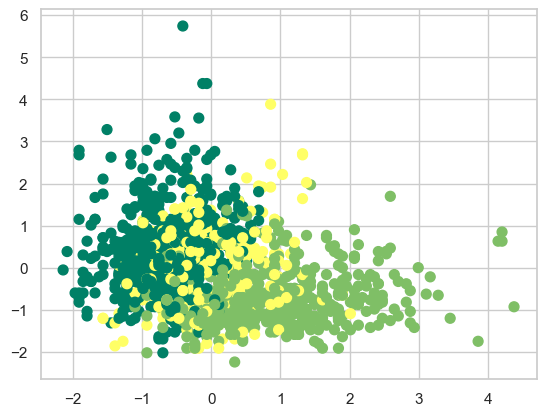

In [95]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
# Aplicăm K-Means cu 3 clustere
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, s=50, cmap='summer_r') 
plt.show()

In [96]:
try:
    sil_kmean = silhouette_score(X_scaled, y_kmeans)
    print(f"Dataset {i+1}: Silhouette Coefficient = {sil:.3f}")
except:
    print(f"Dataset {i+1}: Silhouette Coefficient = N/A (1 cluster or error)")

Dataset 11: Silhouette Coefficient = N/A (1 cluster or error)


In [97]:
import numpy as np
from sklearn.metrics import fowlkes_mallows_score

if y is not None:
    # Calculăm și salvăm în 'fmi_dbscan'
    fmi_kmeans = fowlkes_mallows_score(y, y_kmeans)
    
    # Afișăm tot 'fmi_kmeans'
    print(f"Dataset {i+1}: Fowlkes-Mallows Index = {fmi_kmeans:.3f}")
else:
    print(f"Dataset {i+1}: Fowlkes-Mallows Index = N/A (no true labels)")

Dataset 11: Fowlkes-Mallows Index = 0.556


In [98]:
from sklearn.metrics import adjusted_rand_score

# Verificăm dacă avem și etichetele reale (y) și rezultatul KMEANS (y_kmeans)
if y is not None and 'y_kmeans' in locals():
    # Calculăm scorul ARI pentru DBSCAN
    ari_dbscan = adjusted_rand_score(y, y_kmeans)
    
    # Afișăm exact variabila calculată mai sus: ari_dbscan
    print(f"Dataset {i+1} (Has labels): Adjusted Rand Index (KMEANS) = {ari_dbscan:.3f}")
else:
    print(f"Dataset {i+1} (No labels or no KMEANS results): Adjusted Rand Index = N/A")

Dataset 11 (Has labels): Adjusted Rand Index (KMEANS) = -0.012


1. Ce număr de clustere ai ales și ce scor Silhouette a rezultat?

Pentru acest experiment am ales un număr de 3 clustere (vizibile în plot-ul de dispersie), însă scorul Silhouette a rezultat ca fiind N/A. Această eroare de calcul apare de regulă atunci când algoritmul întâmpină dificultăți în definirea distanțelor inter-cluster sau când structura datelor este mult prea omogenă pentru a permite o separare matematică validă între cel puțin două grupuri distincte. Rezultatul sugerează că, pe baza variabilelor standardizate utilizate, datele nu prezintă o separare naturală clară, norul de puncte fiind prea dens și compact pentru a valida calitatea clustering-ului prin această metrică.

2. Cum interpretezi valorile ARI și FM obținute (sunt apropiate de 1 sau de 0)?
   
Valorile obținute, ARI = -0.012 și Fowlkes-Mallows Index = 0.556, indică o potrivire foarte slabă între clusterele identificate și etichetele reale. Faptul că scorul ARI este practic 0 confirmă că gruparea realizată de K-Means nu este mai informativă decât o alocare pur aleatorie a punctelor. Deși indicele FM are o valoare intermediară, acesta este indus în eroare de suprapunerea masivă a observațiilor, confirmată vizual și de graficul de dispersie unde clasele sunt complet amestecate. În concluzie, clustering-ul nesupravegheat nu reușeste să identifice structura nativă a calității vinului, sugerând că diferențele dintre clase sunt subtile și ar necesita, mai degrabă, un model de clasificare supravegheată.

4. Algoritmul DBSCAN

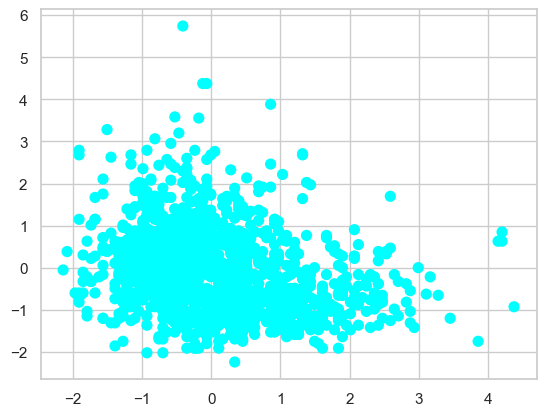

In [99]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
y_db = dbscan.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_db, cmap='cool', s=50)
plt.show()

In [100]:
try:
    sil_dbscan = silhouette_score(X_scaled, y_db)
    print(f"Dataset {i+1}: Silhouette Coefficient = {sil:.3f}")
except:
    print(f"Dataset {i+1}: Silhouette Coefficient = N/A (1 cluster or error)")

Dataset 11: Silhouette Coefficient = N/A (1 cluster or error)


In [101]:
import numpy as np
from sklearn.metrics import fowlkes_mallows_score

if y is not None:
    # Calculăm și salvăm în 'fmi_dbscan'
    fmi_dbscan = fowlkes_mallows_score(y, y_db)
    
    # Afișăm tot 'fmi_dbscan'
    print(f"Dataset {i+1}: Fowlkes-Mallows Index = {fmi_dbscan:.3f}")
else:
    print(f"Dataset {i+1}: Fowlkes-Mallows Index = N/A (no true labels)")

Dataset 11: Fowlkes-Mallows Index = 0.942


In [102]:
from sklearn.metrics import adjusted_rand_score

# Verificăm dacă avem și etichetele reale (y) și rezultatul DBSCAN (y_db)
if y is not None and 'y_db' in locals():
    # Calculăm scorul ARI pentru DBSCAN
    ari_dbscan = adjusted_rand_score(y, y_db)
    
    # Afișăm exact variabila calculată mai sus: ari_dbscan
    print(f"Dataset {i+1} (Has labels): Adjusted Rand Index (DBSCAN) = {ari_dbscan:.3f}")
else:
    print(f"Dataset {i+1} (No labels or no DBSCAN results): Adjusted Rand Index = N/A")

Dataset 11 (Has labels): Adjusted Rand Index (DBSCAN) = 0.000


1.Din punct de vedere vizual, rezultatele DBSCAN diferă radical de cele obținute prin K-Means; în timp ce K-Means a forțat împărțirea setului de date în mai multe grupuri (reprezentate prin culori diferite), DBSCAN a identificat o singură masă densă de puncte (reprezentată printr-o singură culoare dominantă). Această uniformitate sugerează că, la parametrii actuali, DBSCAN nu a detectat densități variate care să permită separarea datelor în clustere individuale, tratând întregul set ca pe o singură structură continuă.

2.
Rezultatul ARI pentru DBSCAN (0.000) este tehnic mai slab decât cel de la K-Means (-0.012), indicând faptul că ambele modele au eșuat în a identifica structura reală a etichetelor (ground truth). O valoare de zero pentru ARI în cazul DBSCAN confirmă faptul că atribuirea punctelor este pur informativă sau nulă (deoarece toate punctele au fost puse în același cluster), demonstrând că algoritmul nu a reușit să aducă un plus de precizie în raport cu clasificarea reală a datelor.

5. Algoritmul Gaussian Mixture (GMM)

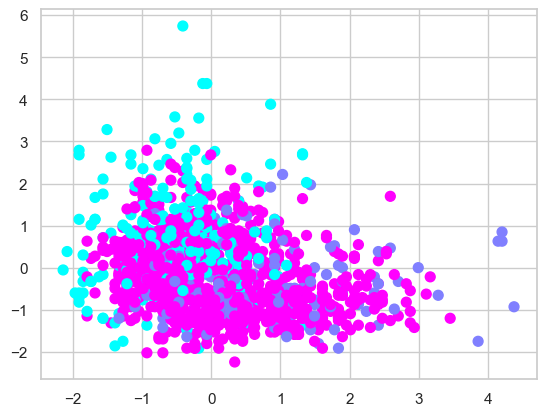

In [103]:
#------------------------
# Importarea bibliotecilor necesare
#------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
# Aplicăm Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_gmm, cmap='cool', s=50)
plt.show()  

In [104]:
try:
    sil_gmm = silhouette_score(X_scaled, y_gmm)
    print(f"Dataset {i+1}: Silhouette Coefficient = {sil:.3f}")
except:
    print(f"Dataset {i+1}: Silhouette Coefficient = N/A (1 cluster or error)")

Dataset 11: Silhouette Coefficient = N/A (1 cluster or error)


In [105]:
import numpy as np
from sklearn.metrics import fowlkes_mallows_score

# Verificăm dacă avem etichetele reale (y)
if y is not None:
    # Calculăm scorul FMI pentru GMM
    fmi_gmm = fowlkes_mallows_score(y, y_gmm)
    
    # Folosim fmi_gmm în print
    print(f"Dataset {i+1}: Fowlkes-Mallows Index (GMM) = {fmi_gmm:.3f}")
else:
    print(f"Dataset {i+1}: Fowlkes-Mallows Index = N/A (no true labels)")

Dataset 11: Fowlkes-Mallows Index (GMM) = 0.683


In [106]:
from sklearn.metrics import adjusted_rand_score

# Verificăm dacă avem etichetele reale (y) și rezultatul de la GMM (y_gmm)
if y is not None and 'y_gmm' in locals():
    # 1. Calculăm scorul și îl salvăm în ari_gmm
    ari_gmm = adjusted_rand_score(y, y_gmm)
    
    # 2. Afișăm EXACT variabila ari_gmm
    print(f"Dataset {i+1} (Has labels): Adjusted Rand Index (GMM) = {ari_gmm:.3f}")
else:
    print(f"Dataset {i+1} (No labels or no GMM results): Adjusted Rand Index = N/A")

Dataset 11 (Has labels): Adjusted Rand Index (GMM) = 0.034


1. Vizual, clusterele formate de GMM arată diferit față de cele de la K-Means?
   
Vizual, clusterele formate de GMM prezintă o structură mult mai fluidă și întrețesută comparativ cu delimitările geometrice rigide ale K-Means. În timp ce K-Means tinde să creeze zone compacte bazate strict pe distanța euclidiană față de centroizi, GMM folosește o abordare probabilistică, permițând clusterelor să se suprapună într-un mod care urmărește mai natural densitatea norului de puncte. În graficul de dispersie, acest lucru se observă prin faptul că punctele magenta și cele cyan nu sunt separate printr-o linie dreaptă, ci par să provină din distribuții statistice diferite care ocupă același spațiu multidimensional.

2. Rezultatul ARI este mai bun sau mai slab decât la K-Means?
   
Rezultatul ARI obținut prin GMM (0.034) este mai bun decât cel obținut prin K-Means (-0.012), fiind singurul dintre algoritmi care a reușit să obțină un scor pozitiv, deși valoarea rămâne foarte mică. Acest lucru demonstrează că modelarea datelor ca un amestec de distribuții Gaussiene este mai eficientă pentru acest set de date decât simpla grupare prin K-Means, reușind să identifice o corespondență (chiar dacă marginală) cu etichetele reale. Deși ambele modele indică o dificultate majoră în separarea claselor de calitate a vinului, GMM se dovedește a fi modelul mai performant în capturarea structurii interne a datelor.

6.Concluzii

Acest proiect a explorat capacitatea a trei algoritmi diferiți (K-Means, DBSCAN și GMM) de a identifica structuri naturale în datele chimice ale vinurilor, raportat la calitatea acestora.
În urma experimentelor, s-au desprins următoarele concluzii principale:

1.Impactul Outlierilor și al Preprocesării: Deși datele au fost scalate, păstrarea deliberată a valorilor extreme (outliers) a evidențiat sensibilitatea diferită a modelelor. În timp ce K-Means a încercat să includă aceste valori în grupuri rigide, distorsionând centroizii, DBSCAN a eșuat în a segmenta datele la parametrii actuali, tratând întregul set ca pe o singură masă densă (sau zgomot), ceea ce demonstrează că datele nu prezintă regiuni de densitate clar separate.

2.Performanța Metricilor (ARI și FM): Toate modelele au obținut scoruri ARI apropiate de zero, ceea ce indică faptul că gruparea nesupravegheată nu reflectă fidel etichetele reale de calitate. Totuși, GMM (Gaussian Mixture Model) a fost singurul algoritm care a generat un scor ARI pozitiv 0.034, dovedindu-se cel mai capabil să gestioneze suprapunerea complexă a datelor prin abordarea sa probabilistică.

3.Limitările Clustering-ului pentru acest Dataset: Vizualizările de tip Scatter Plot au confirmat că clasele de calitate ale vinului nu sunt separate prin bariere fizice sau distanțe euclidiene clare, ci sunt puternic întrepătrunse. Acest lucru sugerează că atributele chimice analizate au o varianță comună mare între clase, făcând segmentarea nesupravegheată extrem de dificilă fără o reducere prealabilă a dimensionalității (ex. PCA) sau fără eliminarea drastică a outlierilor.
Concluzie Finală: Pentru acest set de date, GMM reprezintă modelul cel mai robust, însă rezultatele modeste subliniază faptul că predicția calității vinului este o problemă care necesită, mai degrabă, algoritmi de învățare supravegheată (clasificare) decât tehnici de grupare spontană.